In [71]:
import easyocr
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# Detect point sur la feuille de marquage

In [72]:
def detect_point_column(image_path):
    # Lire l'image
    image = cv2.imread(image_path)

    # Convertir l'image en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Utiliser EasyOCR pour extraire le texte de l'image
    reader = easyocr.Reader(['fr'])  # Spécifiez la langue, par exemple 'fr' pour le français
    result = reader.readtext(gray)

    # Afficher le texte extrait (pour débogage)
    print("Texte extrait de l'image :")
    for (bbox, text, prob) in result:
        print(f"Texte: {text}, Probabilité: {prob}, Bounding box: {bbox}")
    return result

In [73]:
path = '.\externe\FeuilleMarquage.png'



# Remplacez 'feuillemarquage.png' et 'feuillemarquage.csv' par les chemins de vos fichiers
result = detect_point_column(path)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


C:\Users\Nathan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\easyocr\detection.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues re

Texte extrait de l'image :
Texte: Nom, Probabilité: 0.8773223237508122, Bounding box: [[123, 39], [149, 39], [149, 51], [123, 51]]
Texte: prenom, Probabilité: 0.9895409642529174, Bounding box: [[209, 39], [253, 39], [253, 51], [209, 51]]
Texte: Mom, Probabilité: 0.44308944625809815, Bounding box: [[299, 39], [325, 39], [325, 51], [299, 51]]
Texte: orenom, Probabilité: 0.7622532222516959, Bounding box: [[387, 39], [429, 39], [429, 51], [387, 51]]
Texte: Equipe 1, Probabilité: 0.9963353120997117, Bounding box: [[53, 65], [99, 65], [99, 79], [53, 79]]
Texte: Equipe 2, Probabilité: 0.9989081819375206, Bounding box: [[53, 99], [99, 99], [99, 113], [53, 113]]
Texte: Npli, Probabilité: 0.9980630874633789, Bounding box: [[63, 153], [89, 153], [89, 167], [63, 167]]
Texte: Point, Probabilité: 0.9997250654772647, Bounding box: [[151, 153], [181, 153], [181, 165], [151, 165]]
Texte: Point Cumulée, Probabilité: 0.918215650356622, Bounding box: [[215, 151], [293, 151], [293, 165], [215, 165]]
Texte:

# Visualisez les donnée

Texte: Nom, Probabilité: 0.8773223237508122, Bounding box: [[123, 39], [149, 39], [149, 51], [123, 51]]
Texte: prenom, Probabilité: 0.9895409642529174, Bounding box: [[209, 39], [253, 39], [253, 51], [209, 51]]
Texte: Mom, Probabilité: 0.44308944625809815, Bounding box: [[299, 39], [325, 39], [325, 51], [299, 51]]
Texte: orenom, Probabilité: 0.7622532222516959, Bounding box: [[387, 39], [429, 39], [429, 51], [387, 51]]
Texte: Equipe 1, Probabilité: 0.9963353120997117, Bounding box: [[53, 65], [99, 65], [99, 79], [53, 79]]
Texte: Equipe 2, Probabilité: 0.9989081819375206, Bounding box: [[53, 99], [99, 99], [99, 113], [53, 113]]
Texte: Npli, Probabilité: 0.9980630874633789, Bounding box: [[63, 153], [89, 153], [89, 167], [63, 167]]
Texte: Point, Probabilité: 0.9997250654772647, Bounding box: [[151, 153], [181, 153], [181, 165], [151, 165]]
Texte: Point Cumulée, Probabilité: 0.918215650356622, Bounding box: [[215, 151], [293, 151], [293, 165], [215, 165]]
Texte: Point, Probabilité: 0.9992

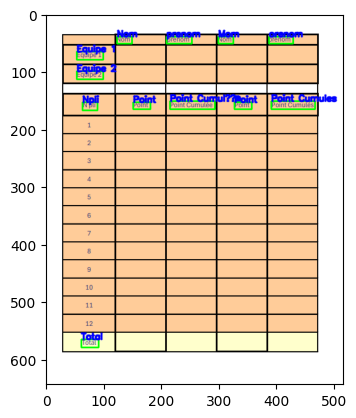

In [74]:
image = cv2.imread(path)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
for (bbox, text, prob) in result:
        print(f"Texte: {text}, Probabilité: {prob}, Bounding box: {bbox}")
        
        # Dessiner la bounding box sur l'image
        top_left = tuple(bbox[0])
        bottom_right = tuple(bbox[2])
        image = cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
        image = cv2.putText(image, text, top_left, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2, cv2.LINE_AA)

# Afficher l'image avec les bounding boxes
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

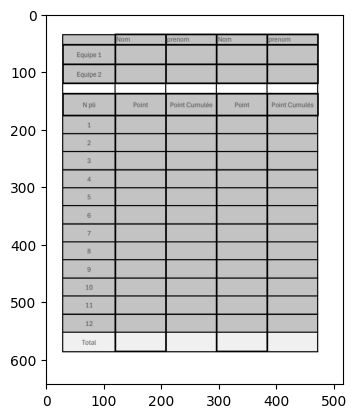

In [75]:
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

Nombre de contours détectés: 261


Nombre de contours: 89


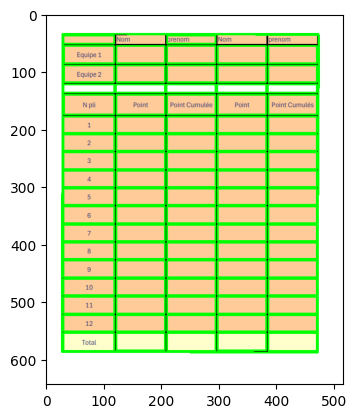

In [76]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt

def detect_contours(frame, index, hierarhie):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 30, 150)
    contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Nombre de contours détectés: {len(contours)}")

    # Convertir les contours en une structure sérialisable
    contours_list = [contour.tolist() for contour in contours]
    hierarchy_list = hierarchy[0].tolist() if hierarchy is not None else []

    # Créer un dictionnaire pour stocker les contours et la hiérarchie
    data = {
        "contours": contours_list,
        "hierarchy": hierarchy_list
    }

    # Enregistrer dans un fichier JSON
    with open(f'contours_hierarchy_{index}.json', 'w') as json_file:
        json.dump(data, json_file, indent=4)


    # Afficher uniquement les trois premiers contours de la hiérarchie
    count = 0
    for i, contour in enumerate(contours):
        if count >= index:
            break
        if hierarchy[0][i][3] <= hierarhie: # Vérifie si le contour est un contour de niveau supérieur
            peri = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
            if len(approx) == 4:  # Vérifie si le contour est approximativement un rectangle
                cv2.drawContours(frame, [approx], -1, (0, 255, 0), 2)
                count += 1
    print(f"Nombre de contours: {count}")
    return frame

# Construit le chemin complet de l'image
frame = cv2.imread(path)
frame_with_contours = detect_contours(frame, 200, 1)
plt.imshow(cv2.cvtColor(frame_with_contours, cv2.COLOR_BGR2RGB))  # Applique la détection de contours
plt.show()
# cv2.imwrite('output.png', frame_with_contours)  # Sauvegarde l'image avec contours

Nombre de contours détectés: 261
Nombre de contours: 89


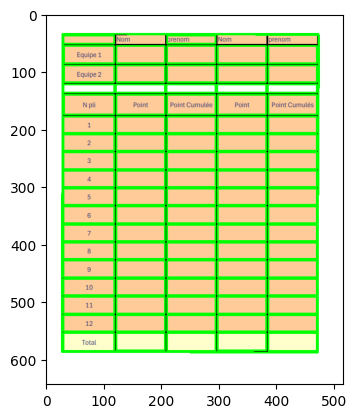

In [83]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt

def detect_contours(frame, index, hierarhie, path):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 30, 150)
    contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Nombre de contours détectés: {len(contours)}")

    # Convertir les contours en une structure sérialisable
    contours_list = [contour.tolist() for contour in contours]
    hierarchy_list = hierarchy[0].tolist() if hierarchy is not None else []

    # Créer un dictionnaire pour stocker les contours et la hiérarchie
    data = {
        "contours": contours_list,
        "hierarchy": hierarchy_list
    }

    # Enregistrer dans un fichier JSON
    with open(path + f'_hierarchy_{index}.json', 'w') as json_file:
        json.dump(data, json_file, indent=4)

    # Afficher uniquement les trois premiers contours de la hiérarchie
    count = 0
    for i, contour in enumerate(contours):
        if count >= index:
            break
        if hierarchy[0][i][3] <= hierarhie:  # Vérifie si le contour est un contour de niveau supérieur
            peri = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
            if len(approx) == 4:  # Vérifie si le contour est approximativement un rectangle
                cv2.drawContours(frame, [approx], -1, (0, 255, 0), 2)
                count += 1

                # Obtenir le rectangle englobant
                x, y, w, h = cv2.boundingRect(contour)
                # Découper la partie de l'image
                roi = frame[y:y+h, x:x+w]
                # Enregistrer la partie de l'image
                cv2.imwrite(path + f'_{x}_{y}_{h}_{w}.png', roi)
    
    print(f"Nombre de contours: {count}")
    return frame

# Construit le chemin complet de l'image
frame = cv2.imread(path)
path_sauvegarde = './externe/contours/'
frame_with_contours = detect_contours(frame, 200, 1, path_sauvegarde)
plt.imshow(cv2.cvtColor(frame_with_contours, cv2.COLOR_BGR2RGB))  # Applique la détection de contours
plt.show()
# cv2.imwrite('output.png', frame_with_contours)  # Sauvegarde l'image avec contours